# 04 · Decision economics - from a score to an action

**Question:** what should Kestrel do with the score, and what is it worth in rupees?

**Data:** walk-forward out-of-fold predictions of the chosen model (3 folds, Jul 2025 – Mar 2026, 6,365 orders), calibrated. Values use **what actually happened** to those orders. The Apr–Jun 2026 holdout is **not** used here. Fold models were trained on 3–9 months, so these ₹ figures are slightly conservative for the shipped 15-month model.

**Assumptions (policy.md §6):** return ₹1,150 (₹600 sensitivity) · call ₹45, prevents 35% of returns · hold > 24 h → 12% cancel · margin on a lost sale **25% of order value (assumption; 15% / 35% sensitivity)** · headline call value ignores the margin a prevented return keeps (conservative).

**Declared before computing:** the recommended default is the **largest top-X% (from 2, 5, 10, 15, 20, 25, 30, 40, 50%) whose marginal band is still net-positive** under the conservative headline accounting. Smaller X are capacity-limited options, not worse ones.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kestrel.config import FIGURES_DIR, MODELS_DIR
from kestrel.economics import Costs, expected_values, call_break_even, realised_value, capacity_table, recommended_share
from kestrel.train import FINAL_CONFIG, SELECTION_END, FOLD_NAMES, load_training_frame, train_final

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
X, y_all, ts, catalogue, pack = load_training_frame()
model_sel, oof = train_final(FINAL_CONFIG, X, y_all, ts, catalogue, end=SELECTION_END)   # holdout untouched
d = oof.copy()
d["p"] = model_sel.calibrator.transform(d.raw)
d["value"] = pack["train"].order_value_inr.to_numpy()[d.index]
d["shield"] = X.shield.to_numpy()[d.index]
d["family"] = X.family.to_numpy()[d.index]
d["month"] = ts.to_numpy()[d.index].astype("datetime64[M]")
ORDERS_PER_MONTH = round(len(pack["test"]) / 3)       # volume of the latest quarter in the export
H = Costs()
print(f"{len(d)} OOF orders, {d.y.sum()} returns ({d.y.mean():.3f}); mean predicted {d.p.mean():.3f}; volume used for monthly figures: {ORDERS_PER_MONTH} orders/month")

6365 OOF orders, 711 returns (0.112); mean predicted 0.112; volume used for monthly figures: 699 orders/month


## 1 · Per-order break-evens

In [2]:
be = {"call pays (conservative, ₹1,150)": call_break_even(costs=H),
      "call pays (conservative, ₹600)": call_break_even(costs=Costs(return_cost=600)),
      "call pays (true, median order ₹%d)" % d.value.median(): float(call_break_even(d.value.median(), Costs(count_margin_in_call=True)))}
print({k: f"{v:.1%}" for k, v in be.items()})
print(f"share of OOF orders above the conservative call break-even: {(d.p > be['call pays (conservative, ₹1,150)']).mean():.1%} (≈ the share of orders a 'call everyone it pays to call' rule would need)")
ev = expected_values(d.p, d.value, H)
print(f"orders where expected hold value > call value: {(ev['hold'] > ev['call']).mean():.2%}; where hold > ship: {(ev['hold'] > 0).mean():.2%}")

{'call pays (conservative, ₹1,150)': '11.2%', 'call pays (conservative, ₹600)': '21.4%', 'call pays (true, median order ₹4392)': '5.7%'}
share of OOF orders above the conservative call break-even: 32.2% (≈ the share of orders a 'call everyone it pays to call' rule would need)
orders where expected hold value > call value: 0.00%; where hold > ship: 1.78%


**Reading:**
- **A call pays for itself above 11.2% risk** (conservative, ₹1,150), or 21.4% at ₹600. Counting the margin a prevented return keeps, a median order (₹4,392) pays from **5.7%**.
- About **32%** of orders sit above 11.2%, so "call everyone it pays to call" is a third of all orders. Capacity, not break-even, decides how many to call.
- **A hold is never better than a call for any order** (0.00%), and is better than doing nothing for only 1.8% of orders.

## 2 · Policies compared (realised outcomes on the walk-forward folds)

In [3]:
order = np.argsort(-d.p.to_numpy())
def top(x):
    s = np.zeros(len(d), bool); s[order[:int(round(x * len(d)))]] = True; return s
policies = {
    "Ship everything (today)": None,
    "Ritu's ask: HOLD top 10%": ("hold", top(0.10)),
    "HOLD top 20%": ("hold", top(0.20)),
    "CALL top 10%": ("call", top(0.10)),
    "CALL top 20%": ("call", top(0.20)),
    "CALL every order above break-even (11.2%)": ("call", (d.p > be["call pays (conservative, ₹1,150)"]).to_numpy()),
}
rows = {}
for name, pol in policies.items():
    if pol is None:
        rows[name] = {"orders_actioned": 0, "precision": np.nan, "returns_avoided": 0, "good_orders_lost": 0, "net": 0.0}
    else:
        rows[name] = realised_value(d.y, d.value, pol[1], pol[0], H)
pt = pd.DataFrame(rows).T[["orders_actioned", "precision", "returns_avoided", "good_orders_lost", "gross_saving", "cost", "net"]]
scale = ORDERS_PER_MONTH / len(d)
pt["net_per_month"] = pt.net * scale
pt["net_per_1000_orders"] = pt.net / len(d) * 1000
pt.round(2)

,orders_actioned,precision,returns_avoided,good_orders_lost,gross_saving,cost,net,net_per_month,net_per_1000_orders
Ship everything (today),0.0,NaN,0.00,0.00,NaN,NaN,0.00,0.00,0.00
Ritu's ask: HOLD top 10%,636.0,0.41,31.08,45.24,35742.0,130187.41,-94445.41,-10371.93,-14838.24
HOLD top 20%,1273.0,0.31,47.16,105.60,54234.0,295170.84,-240936.84,-26459.52,-37853.39
CALL top 10%,636.0,0.41,90.65,0.00,104247.5,28620.00,75627.50,8305.36,11881.78
CALL top 20%,1273.0,0.31,137.55,0.00,158182.5,57285.00,100897.50,11080.50,15851.92
CALL every order above break-even (11.2%),2051.0,0.24,168.70,0.00,194005.0,92295.00,101710.00,11169.72,15979.58


**Reading: holding loses money; calling makes it.**
- **Ritu's ask (hold the top 10%) loses ~₹10,400/month** at the export's volume (−₹14,800 per 1,000 orders). It avoids ~31 returns over the three quarters but cancels ~45 good orders, and their lost margin (high-value robot vacuums and purifiers dominate the top 10%) outweighs the ₹1,150 saved per avoided return. Holding the top 20% is worse (−₹26,500/month).
- **Calling the same top 10% makes ~+₹8,300/month**: the same orders, about 3× as many returns avoided (35% vs 12%), no lost sales.

## 3 · Capacity table - call the top X% the team can handle

In [4]:
cap = capacity_table(d.p, d.y, d.value, costs=H, orders_per_month=ORDERS_PER_MONTH)
X_REC = recommended_share(cap)
cap_600 = capacity_table(d.p, d.y, d.value, costs=Costs(return_cost=600), orders_per_month=ORDERS_PER_MONTH)
cap_true = capacity_table(d.p, d.y, d.value, costs=Costs(count_margin_in_call=True), orders_per_month=ORDERS_PER_MONTH)
cap["net_per_month @₹600"] = cap_600.net_per_month
cap["net_per_month incl. kept margin"] = cap_true.net_per_month
cap["calls_per_day"] = cap.actions_per_month / 30
print(f"recommended default (declared rule): top {X_REC:.0%} | at ₹600 the same rule gives top {recommended_share(cap_600):.0%}")
cap[["score_cutoff", "orders", "calls_per_day", "precision", "recall", "band_precision", "band_net_per_order", "returns_avoided_per_month",
     "net_per_month", "net_per_month @₹600", "net_per_month incl. kept margin", "net_per_1000_orders"]].round(3)

recommended default (declared rule): top 25% | at ₹600 the same rule gives top 15%


,score_cutoff,orders,calls_per_day,precision,recall,band_precision,band_net_per_order,returns_avoided_per_month,net_per_month,net_per_month @₹600,net_per_month incl. kept margin,net_per_1000_orders
top_share,,,,,,,,,,,,
0.02,0.508,127,0.465,0.654,0.117,0.654,218.051,3.190,3041.172,1286.533,13181.783,4350.746
0.05,0.358,318,1.164,0.516,0.231,0.424,125.694,6.304,5677.659,2210.663,25589.078,8122.545
0.10,0.247,636,2.328,0.407,0.364,0.299,75.244,9.955,8305.361,2830.044,38960.120,11881.775
0.15,0.194,955,3.496,0.347,0.466,0.226,45.846,12.723,9911.469,2914.056,48377.998,14179.497
0.20,0.160,1273,4.660,0.309,0.553,0.195,33.475,15.106,11080.495,2772.389,56438.524,15851.925
0.25,0.137,1591,5.824,0.273,0.612,0.132,8.160,16.720,11365.476,2169.481,61369.383,16259.623
0.30,0.118,1910,6.992,0.245,0.657,0.100,-4.624,17.950,11203.493,1331.010,64705.695,16027.887
0.40,0.090,2546,9.320,0.209,0.747,0.101,-4.497,20.410,10889.410,-336.047,70748.677,15578.555
0.50,0.070,3182,11.648,0.184,0.826,0.088,-9.560,22.562,10221.708,-2187.601,76542.190,14623.331


**Reading: the capacity curve.** Net value climbs steeply up to ~10–15% of orders and flattens around **20–30%**. The marginal band 25–30% is already slightly negative (band precision 10.0% < 11.2% break-even). By the declared rule, the **recommended default is the top 25%**: ~175 calls/month (**~6 a day**) at the export's volume, **27%** of called orders would otherwise return (2.4× the base rate), covering **61% of all returns**, net **~₹11,400/month = ₹16,260 per 1,000 orders**.
- If the team can only take fewer: top 10% (~2–3 calls a day) already earns 73% of that value (₹8,300/month); top 5% earns 50%.
- At ₹600 per return the same rule says **top 15%** (₹2,900/month), still positive.
- Counting the margin a prevented return keeps (true accounting), the value is ~5× higher (₹61,400/month at top 25%), so the headline is deliberately conservative.

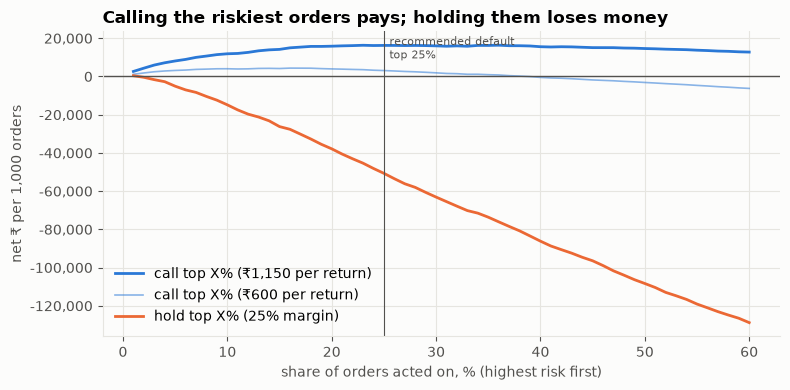

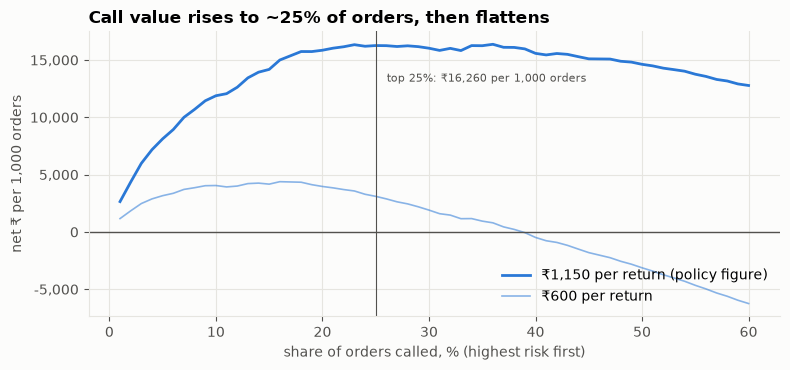

In [5]:
BLUE, ORANGE, INK, INK2, GRID, SURFACE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e6e5e0", "#fcfcfb"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE, "axes.edgecolor": GRID,
                     "axes.grid": True, "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "legend.frameon": False})
shares = np.round(np.arange(0.01, 0.61, 0.01), 2)
fine = capacity_table(d.p, d.y, d.value, shares=tuple(shares), costs=H, orders_per_month=ORDERS_PER_MONTH)
fine_h = capacity_table(d.p, d.y, d.value, shares=tuple(shares), action="hold", costs=H, orders_per_month=ORDERS_PER_MONTH)
fine_600 = capacity_table(d.p, d.y, d.value, shares=tuple(shares), costs=Costs(return_cost=600), orders_per_month=ORDERS_PER_MONTH)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(shares * 100, fine.net_per_1000_orders, color=BLUE, lw=2, label="call top X% (₹1,150 per return)")
ax.plot(shares * 100, fine_600.net_per_1000_orders, color=BLUE, lw=1.2, alpha=0.55, label="call top X% (₹600 per return)")
ax.plot(shares * 100, fine_h.net_per_1000_orders, color=ORANGE, lw=2, label="hold top X% (25% margin)")
ax.axhline(0, color=INK2, lw=1)
ax.axvline(X_REC * 100, color=INK2, lw=0.8)
ax.annotate(f"recommended default\ntop {X_REC:.0%}", xy=(X_REC * 100, ax.get_ylim()[1] * 0.92), ha="left", va="top", fontsize=8, color=INK2, xytext=(4, 0), textcoords="offset points")
ax.set_xlabel("share of orders acted on, % (highest risk first)"); ax.set_ylabel("net ₹ per 1,000 orders")
ax.set_title("Calling the riskiest orders pays; holding them loses money", loc="left")
ax.legend(loc="lower left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
fig.tight_layout(); fig.savefig(FIGURES_DIR / "04_call_vs_hold_net.png", dpi=150); plt.show()

# Call-only view: where does adding more calls stop paying?
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(shares * 100, fine.net_per_1000_orders, color=BLUE, lw=2, label="₹1,150 per return (policy figure)")
ax.plot(shares * 100, fine_600.net_per_1000_orders, color=BLUE, lw=1.2, alpha=0.55, label="₹600 per return")
ax.axhline(0, color=INK2, lw=1); ax.axvline(X_REC * 100, color=INK2, lw=0.8)
peak = fine.net_per_1000_orders.idxmax()
ax.annotate(f"top {X_REC:.0%}: ₹{cap.loc[X_REC, 'net_per_1000_orders']:,.0f} per 1,000 orders", xy=(X_REC * 100, cap.loc[X_REC, "net_per_1000_orders"]),
            xytext=(8, -26), textcoords="offset points", fontsize=8, color=INK2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("share of orders called, % (highest risk first)"); ax.set_ylabel("net ₹ per 1,000 orders")
ax.set_title("Call value rises to ~25% of orders, then flattens", loc="left"); ax.legend(loc="lower right")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "04_call_capacity.png", dpi=150); plt.show()

## 4 · Sensitivity at the recommended default

In [6]:
sel = top(X_REC)
rows = []
for rc in (600, 1150):
    for prev in (0.25, 0.35, 0.45):
        for mr in (0.15, 0.25, 0.35):
            c = Costs(return_cost=rc, prevention=prev, margin_rate=mr)
            call, hold = realised_value(d.y, d.value, sel, "call", c), realised_value(d.y, d.value, sel, "hold", c)
            rows.append({"return_cost": rc, "prevention": prev, "margin": mr, "call_net_per_month": call["net"] * scale,
                         "hold_net_per_month": hold["net"] * scale, "calls_beat_holds": call["net"] > hold["net"], "call_positive": call["net"] > 0})
sens = pd.DataFrame(rows)
print(f"top {X_REC:.0%}: calls beat holds in {sens.calls_beat_holds.mean():.0%} of 18 scenarios; call net positive in {sens.call_positive.mean():.0%}")
sens.round({"call_net_per_month": 0, "hold_net_per_month": 0})

top 25%: calls beat holds in 100% of 18 scenarios; call net positive in 83%


,return_cost,prevention,margin,call_net_per_month,hold_net_per_month,calls_beat_holds,call_positive
0,600,0.25,0.15,-697.0,-21771.0,True,False
1,600,0.25,0.25,-697.0,-38578.0,True,False
2,600,0.25,0.35,-697.0,-55385.0,True,False
3,600,0.35,0.15,2169.0,-21771.0,True,True
4,600,0.35,0.25,2169.0,-38578.0,True,True
5,600,0.35,0.35,2169.0,-55385.0,True,True
6,600,0.45,0.15,5036.0,-21771.0,True,True
7,600,0.45,0.25,5036.0,-38578.0,True,True
8,600,0.45,0.35,5036.0,-55385.0,True,True
9,1150,0.25,0.15,5872.0,-18618.0,True,True


**Reading:** at the top 25%, **calls beat holds in all 18 scenarios** (return cost ₹600/₹1,150 × prevention 25/35/45% × margin 15/25/35%). The call is net-positive in 15 of 18; the three negatives are all ₹600 with only 25% prevention. Holds lose ₹18,600–55,400/month in every scenario.

## 5 · Shield view

In [7]:
rows = []
for x in (0.05, 0.10, 0.20, X_REC):
    s = top(x)
    rows.append({"top_share": x, "flagged": int(s.sum()), "shield_share_of_flagged": d.shield[s].mean(),
                 "shield_share_of_all_orders": d.shield.mean(), "precision_shield": d.y[s & (d.shield == 1)].mean(),
                 "precision_non_shield": d.y[s & (d.shield == 0)].mean()})
shield_t = pd.DataFrame(rows).drop_duplicates("top_share").set_index("top_share").round(3)
shield_t

,flagged,shield_share_of_flagged,shield_share_of_all_orders,precision_shield,precision_non_shield
top_share,,,,,
0.05,318,0.494,0.219,0.522,0.509
0.10,636,0.489,0.219,0.412,0.403
0.20,1273,0.447,0.219,0.327,0.294
0.25,1591,0.421,0.219,0.296,0.257


In [8]:
s = top(X_REC)
held_shield_cancels = HOLD_CANCEL = H.cancel * (s & (d.shield == 1)).sum() * scale
print(f"If Ritu's hold were applied at top {X_REC:.0%}: ~{held_shield_cancels:.1f} Shield orders/month cancelled "
      f"(Shield = highest-lifetime-value segment, ~3 appliances/year per Meenal). A call puts no order at risk.")
by_fam = pd.DataFrame({"flagged_share_of_family": pd.Series(s).groupby(d.family.to_numpy()).mean(),
                       "precision_in_family": pd.Series(d.y.to_numpy()[s]).groupby(d.family.to_numpy()[s]).mean()}).round(3)
by_fam

If Ritu's hold were applied at top 25%: ~8.8 Shield orders/month cancelled (Shield = highest-lifetime-value segment, ~3 appliances/year per Meenal). A call puts no order at risk.


,flagged_share_of_family,precision_in_family
Air Fryer,0.303,0.265
Ceiling Fan,0.115,0.267
Induction Cooktop,0.112,0.276
Mixer Grinder,0.106,0.207
Robot Vacuum,0.476,0.319
Room Heater,0.245,0.239
Water Purifier,0.392,0.264


**Reading: Shield.** A risk model naturally flags Shield members at about **twice their share**: 42–49% of flagged orders vs 22% of all orders. That isn't bias: flagged Shield and non-Shield orders come back at the same rate (29.6% vs 25.7% at top 25%). Holding them would cancel ~9 Shield orders a month from the highest-lifetime-value segment. **A call doesn't put the order at risk, so the rule is "call, don't hold" for everyone, and Shield is one more reason never to hold.** By family, robot vacuums (48% flagged) and water purifiers (39%) dominate the call list; fans, mixers and cooktops are ~11%.

## 6 · In Ritu's language

In [9]:
r = cap.loc[X_REC]
print(f"Call the riskiest {X_REC:.0%} of orders (~{r.actions_per_month:.0f} calls/month, ~{r.calls_per_day:.1f}/day at the export's volume):")
print(f"  - {r.precision:.0%} of the orders we call would otherwise come back (vs {d.y.mean():.0%} of all orders: {r.precision / d.y.mean():.1f}x)")
print(f"  - they hold {r.recall:.0%} of all returns; calls avoid ~{r.returns_avoided_per_month:.1f} returns/month")
print(f"  - net ~₹{r.net_per_month:,.0f}/month (₹{r.net_per_1000_orders:,.0f} per 1,000 orders); ₹{cap.loc[X_REC, 'net_per_month @₹600']:,.0f}/month at ₹600 per return")
h10 = pt.loc["Ritu's ask: HOLD top 10%"]
print(f"Ritu's hold-the-top-10% instead: net ₹{h10.net_per_month:,.0f}/month, losing ~{h10.good_orders_lost * scale:.1f} good orders/month to cancellation")

Call the riskiest 25% of orders (~175 calls/month, ~5.8/day at the export's volume):
  - 27% of the orders we call would otherwise come back (vs 11% of all orders: 2.4x)
  - they hold 61% of all returns; calls avoid ~16.7 returns/month
  - net ~₹11,365/month (₹16,260 per 1,000 orders); ₹2,169/month at ₹600 per return
Ritu's hold-the-top-10% instead: net ₹-10,372/month, losing ~5.0 good orders/month to cancellation


In [10]:
import json
decision = {"recommended_top_share": float(X_REC),
            "score_cutoff_for_call": float(cap.loc[X_REC, "score_cutoff"]),
            "capacity_options": {f"{x:.0%}": float(cap.loc[x, "score_cutoff"]) for x in cap.index},
            "costs": H.as_dict(), "orders_per_month_in_export": ORDERS_PER_MONTH,
            "rule": "call orders whose calibrated risk is at or above the cutoff for the chosen capacity; never hold"}
meta_path = MODELS_DIR / "model_meta.json"
meta = json.loads(meta_path.read_text(encoding="utf-8")); meta["decision"] = decision
meta_path.write_text(json.dumps(meta, indent=2, default=str), encoding="utf-8")
decision

{'recommended_top_share': 0.25,
 'score_cutoff_for_call': 0.13650268998194356,
 'capacity_options': {'2%': 0.5083367971965665,
  '5%': 0.35832211144019854,
  '10%': 0.24710052818228148,
  '15%': 0.19432572470865433,
  '20%': 0.16049407012564057,
  '25%': 0.13650268998194356,
  '30%': 0.11834848448766053,
  '40%': 0.09015582048924796,
  '50%': 0.07013472045909871},
 'costs': {'return_cost': 1150,
  'call_cost': 45,
  'prevention': 0.35,
  'cancel': 0.12,
  'margin_rate': 0.25,
  'count_margin_in_call': False},
 'orders_per_month_in_export': 699,
 'rule': 'call orders whose calibrated risk is at or above the cutoff for the chosen capacity; never hold'}

## 7 · Decision (saved to `model_meta.json` → `decision`)
| Rule | Value |
|---|---|
| Action | **Call** orders whose calibrated risk ≥ the cutoff for the chosen capacity. **Never hold.** |
| Default capacity | **Top 25%** of orders → risk cutoff **13.7%** (~6 calls/day at the export's volume) |
| Capacity options | top 5% → 35.8%, 10% → 24.7%, 15% → 19.4%, 20% → 16.0%, 30% → 11.8% |
| Shield | Call like anyone else; never hold |
| ₹ (conservative, ₹1,150) | ~₹16,300 net per 1,000 orders at top 25%; ₹11,900 at top 10% |